In [1]:
import torch
import sklearn
import numpy as np
from statsmodels.multivariate.manova import MANOVA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import umap
import pandas as pd

In [21]:
w1 = np.stack(torch.load("weights_1_5.pt"))
w2 = np.stack(torch.load("weights_2_5.pt"))
b1 = np.stack(torch.load("bias_1_5.pt"))
b2 = np.stack(torch.load("bias_2_5.pt"))
act1 = torch.stack(torch.load("activations_1_5.pt")).cpu().detach().numpy().mean(axis=1)
act2 = torch.stack(torch.load("activations_2_5.pt")).cpu().detach().numpy().mean(axis=1)
labels = torch.load("labels_5.pt")
print(w1.shape, w2.shape, b1.shape, b2.shape, act1.shape, act2.shape)

(1377, 131072) (1377, 16128) (1377, 256) (1377, 63) (1377, 256) (1377, 63)


/home/cactus/miniforge3/envs/metalearning-hope/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


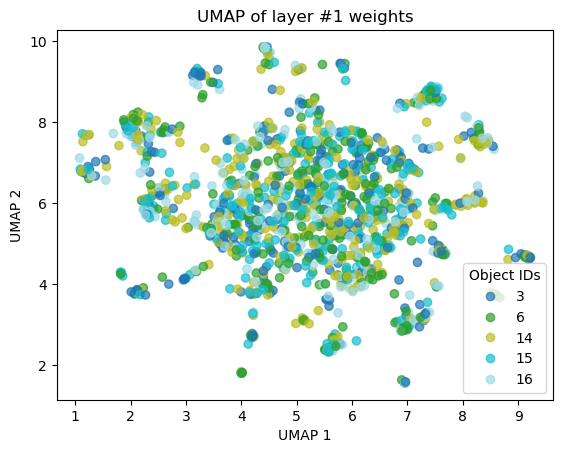

/home/cactus/miniforge3/envs/metalearning-hope/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


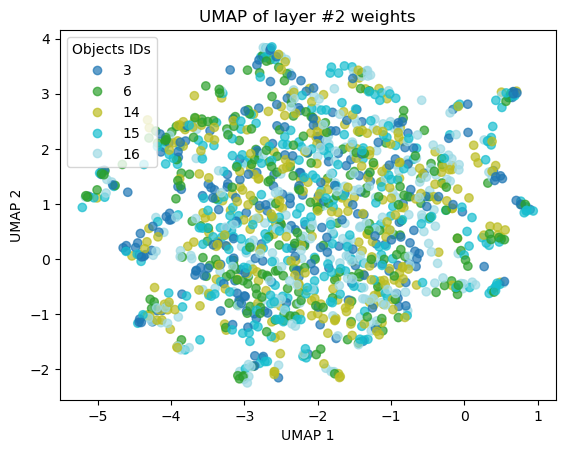

/home/cactus/miniforge3/envs/metalearning-hope/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


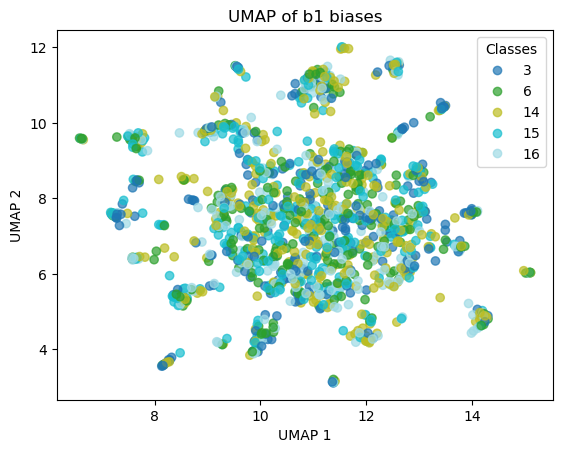

/home/cactus/miniforge3/envs/metalearning-hope/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


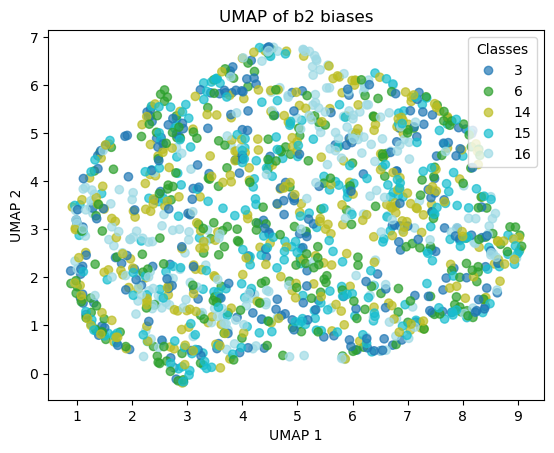

In [49]:
reducer = umap.UMAP()
umap_w1 = reducer.fit_transform(StandardScaler().fit_transform(w1))
scatter = plt.scatter(umap_w1[:,0], umap_w1[:,1], c=labels, cmap='tab20', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Object IDs")
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title(f'UMAP of layer #1 weights')
plt.savefig("umap_w1.png")
plt.show()

umap_w2 = reducer.fit_transform(StandardScaler().fit_transform(w2))
scatter = plt.scatter(umap_w2[:,0], umap_w2[:,1], c=labels, cmap='tab20', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Objects IDs")
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title(f'UMAP of layer #2 weights')
plt.savefig("umap_w2.png")
plt.show()

umap_b1 = reducer.fit_transform(StandardScaler().fit_transform(b1))
scatter = plt.scatter(umap_b1[:,0], umap_b1[:,1], c=labels, cmap='tab20', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title(f'UMAP of b1 biases')
plt.show()

umap_b2 = reducer.fit_transform(StandardScaler().fit_transform(b2))
scatter = plt.scatter(umap_b2[:,0], umap_b2[:,1], c=labels, cmap='tab20', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title(f'UMAP of b2 biases')
plt.show()

In [ ]:
umap_act1 = reducer.fit_transform(StandardScaler().fit_transform(act1))
scatter = plt.scatter(umap_act1[:,0], umap_act1[:,1], c=labels, cmap='tab20', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title(f'UMAP of activations 1')
plt.show()

umap_act2 = reducer.fit_transform(StandardScaler().fit_transform(act2))
scatter = plt.scatter(umap_act2[:,0], umap_act2[:,1], c=labels, cmap='tab20', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title(f'UMAP of activations 2')
plt.show()

In [9]:
per_group_samples = []
indices = np.arange(len(labels))
n_components_w1, n_components_w2, n_components_b1, n_components_b2 = 20, 10, 5, 5
print(f"Computing PCA...")
pca1 = sklearn.decomposition.PCA(n_components=n_components_w1)
pca2 = sklearn.decomposition.PCA(n_components=n_components_w2)
pca3 = sklearn.decomposition.PCA(n_components=n_components_b1)
pca4 = sklearn.decomposition.PCA(n_components=n_components_b2)
pca_w1 = pca1.fit_transform(w1)
pca_w2 = pca2.fit_transform(w2)
pca_b1 = pca3.fit_transform(b1)
pca_b2 = pca4.fit_transform(b2)
print(f"Output shape: {pca_w1.shape}, {pca_w2.shape}, {pca_b1.shape}, {pca_b2.shape}")
print(f"Pct of variance explained by principal components (W1): min={pca1.explained_variance_ratio_.cumsum().min()}, max={pca1.explained_variance_ratio_.cumsum().max()}")
print(f"Pct of variance explained by principal components (W2): min={pca2.explained_variance_ratio_.cumsum().min()}, max={pca2.explained_variance_ratio_.cumsum().max()}")
print(f"Pct of variance explained by principal components (B1): min={pca3.explained_variance_ratio_.cumsum().min()}, max={pca3.explained_variance_ratio_.cumsum().max()}")
print(f"Pct of variance explained by principal components (B2): min={pca4.explained_variance_ratio_.cumsum().min()}, max={pca4.explained_variance_ratio_.cumsum().max()}")

Computing PCA...
Output shape: (1377, 20), (1377, 10), (1377, 5), (1377, 5)
Pct of variance explained by principal components (W1): min=0.17491582036018372, max=0.9030331969261169
Pct of variance explained by principal components (W2): min=0.39075684547424316, max=0.9662015438079834
Pct of variance explained by principal components (B1): min=0.19230560958385468, max=0.6516509652137756
Pct of variance explained by principal components (B2): min=0.8911600708961487, max=0.9329303503036499


In [29]:
print("Running MANOVA on PCA reduced embedding vectors...")
pcaa = sklearn.decomposition.PCA(n_components=10)
pca_vec=pcaa.fit_transform(act1)
cond_number = np.linalg.cond(pcaa.components_)
print(f"PCA condition number: {cond_number:.2e}")  
# Good: <1e3, Acceptable: <1e4, Problematic: >1e4
df = pd.DataFrame(StandardScaler().fit_transform(pca_vec), columns=[f'Dim{i}' for i in range(pca_vec.shape[1])])
df['labels'] = pd.Categorical(labels)
# print(df)
dependent_vars = ' + '.join(df.columns[:-1])
manova_formula = f'{dependent_vars} ~ C(labels)'
manova = MANOVA.from_formula(manova_formula, data=df)
# Dependent variables are Principal Component Vectors, independent variabel is label
print(manova.mv_test().summary())

Running MANOVA on PCA reduced embedding vectors...
PCA condition number: 1.00e+00
                   Multivariate linear model
                                                               
---------------------------------------------------------------
       Intercept        Value   Num DF   Den DF  F Value Pr > F
---------------------------------------------------------------
          Wilks' lambda 0.9613 10.0000 1363.0000  5.4819 0.0000
         Pillai's trace 0.0387 10.0000 1363.0000  5.4819 0.0000
 Hotelling-Lawley trace 0.0402 10.0000 1363.0000  5.4819 0.0000
    Roy's greatest root 0.0402 10.0000 1363.0000  5.4819 0.0000
---------------------------------------------------------------
                                                               
---------------------------------------------------------------
       C(labels)        Value   Num DF   Den DF  F Value Pr > F
---------------------------------------------------------------
          Wilks' lambda 0.8013 40.0000 51

Running MANOVA on principal components...
---------------- W1 --------------
MANOVA formula: PC0 + PC1 + PC2 + PC3 + PC4 + PC5 + PC6 + PC7 + PC8 + PC9 + PC10 + PC11 + PC12 + PC13 + PC14 + PC15 + PC16 + PC17 + PC18 + PC19 ~ C(labels)
                   Multivariate linear model
                                                               
---------------------------------------------------------------
       Intercept        Value   Num DF   Den DF  F Value Pr > F
---------------------------------------------------------------
          Wilks' lambda 0.9351 20.0000 1353.0000  4.6945 0.0000
         Pillai's trace 0.0649 20.0000 1353.0000  4.6945 0.0000
 Hotelling-Lawley trace 0.0694 20.0000 1353.0000  4.6945 0.0000
    Roy's greatest root 0.0694 20.0000 1353.0000  4.6945 0.0000
---------------------------------------------------------------
                                                               
---------------------------------------------------------------
       C(labels)  

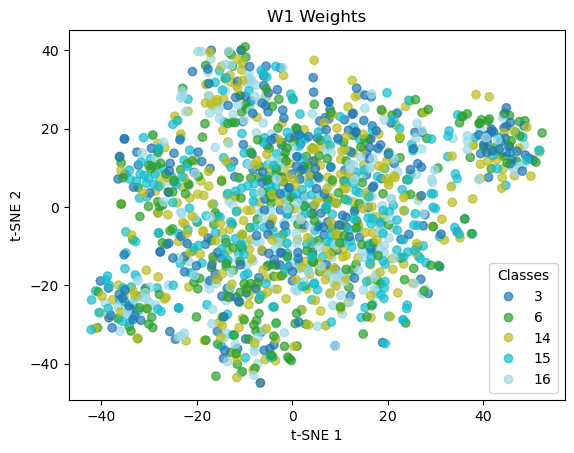

ANOVA results of classification:
(array([ 2.6924262,  2.9730031,  2.0472336,  2.1228516,  1.3128754,
        2.2717464, 16.681002 ,  1.150663 ,  5.4127417,  0.277968 ,
        2.5863032,  2.8503597,  3.846619 ,  9.947625 ,  1.4851698,
       11.341983 ,  3.2908645,  0.8041161,  1.3020688,  3.1680524],
      dtype=float32), array([2.9703520e-02, 1.8507086e-02, 8.5527159e-02, 7.5758830e-02,
       2.6304182e-01, 5.9528787e-02, 2.3357770e-13, 3.3105069e-01,
       2.5226708e-04, 8.9232671e-01, 3.5459202e-02, 2.2777446e-02,
       4.0960312e-03, 6.1767359e-08, 2.0427129e-01, 4.6643058e-09,
       1.0749474e-02, 5.2250510e-01, 2.6717243e-01, 1.3271315e-02],
      dtype=float32))


/tmp/ipykernel_1398233/29070392.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  class_means = df.groupby('labels').mean().T


Text(0, 0.5, 'PCA Component')

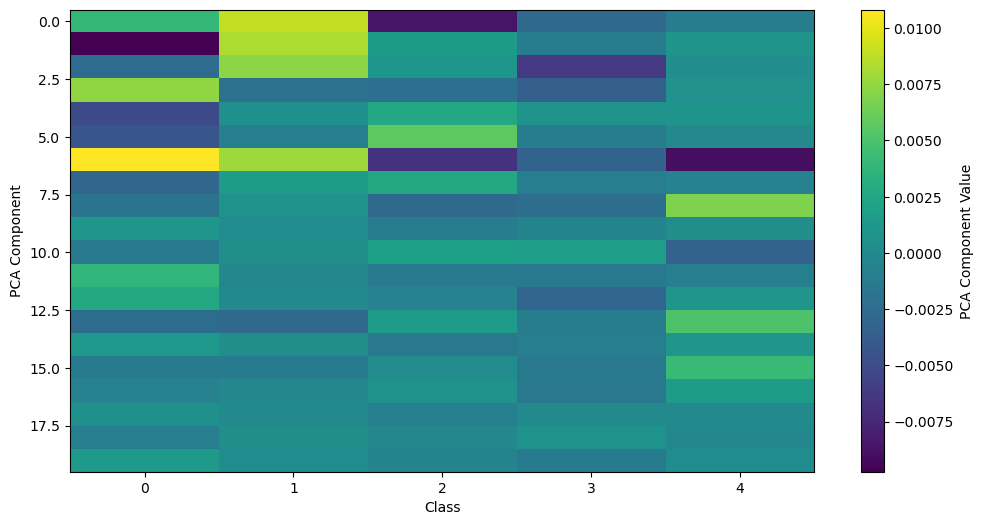

In [10]:
print("Running MANOVA on principal components...")
# Create a design matrix with intercept + group indicators
# (One-hot encode groups, dropping the first group to avoid multicollinearity)
group_labels = np.array(labels)
unique_groups = np.unique(group_labels)
n_unique = len(unique_groups)
n_samples =  pca_w1.shape[0]
print("---------------- W1 --------------")
# manova_model = MANOVA(pca_w1, design_matrix)
# # Test the hypothesis: "Do groups affect the PCA-transformed weights?"
# hypothesis_matrix = np.eye(design_matrix.shape[1])[1:]  # Test all group coefficients (ignore intercept)
# result = manova_model.mv_test(hypotheses=[('group_effect', hypothesis_matrix)])
# # Print results
# print(result.summary())
df = pd.DataFrame(pca_w1, columns=[f'PC{i}' for i in range(n_components_w1)])
df['labels'] = pd.Categorical(labels)
# print(df)
dependent_vars = ' + '.join(df.columns[:-1])
manova_formula = f'{dependent_vars} ~ C(labels)'
print(f"MANOVA formula: {manova_formula}")
manova = MANOVA.from_formula(manova_formula, data=df)
# Dependent variables are Principal Component Vectors, independent variabel is label
print(manova.mv_test().summary())
# Project PCA-transformed data to 2D
w1_tsne = TSNE(n_components=2,max_iter=3000).fit_transform(StandardScaler().fit_transform(pca_w1))
# Plot with group colors
scatter = plt.scatter(w1_tsne[:,0], w1_tsne[:,1], c=labels, cmap='tab20', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title(f'W1 Weights')
plt.show()
print("ANOVA results of classification:")
print(sklearn.feature_selection.f_classif(pca_w1, np.array(group_labels)))
# Plot class means in PCA space
class_means = df.groupby('labels').mean().T
plt.figure(figsize=(12,6))
plt.imshow(class_means, aspect='auto', cmap='viridis')
plt.colorbar(label='PCA Component Value')
plt.xlabel('Class')
plt.ylabel('PCA Component')

Running MANOVA on principal components...
Design matrix: [[1. 0. 0. 0. 1.]
 [1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 ...
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 1.]
 [1. 0. 1. 0. 0.]]
---------------- W1 --------------
                   Multivariate linear model
                                                                
----------------------------------------------------------------
      group_effect      Value   Num DF    Den DF  F Value Pr > F
----------------------------------------------------------------
          Wilks' lambda 0.6724 128.0000 5337.4085  4.3755 0.0000
         Pillai's trace 0.3718 128.0000 5376.0000  4.3045 0.0000
 Hotelling-Lawley trace 0.4248 128.0000 4692.7726  4.4460 0.0000
    Roy's greatest root 0.2031  32.0000 1344.0000  8.5292 0.0000



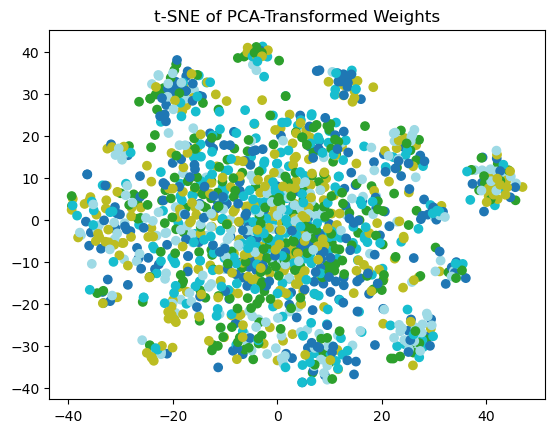

---------------- W2 --------------
                   Multivariate linear model
                                                               
---------------------------------------------------------------
      group_effect      Value   Num DF   Den DF  F Value Pr > F
---------------------------------------------------------------
          Wilks' lambda 0.6637 64.0000 5314.6914  9.1655 0.0000
         Pillai's trace 0.3731 64.0000 5440.0000  8.7435 0.0000
 Hotelling-Lawley trace 0.4527 64.0000 4249.5765  9.5897 0.0000
    Roy's greatest root 0.2919 16.0000 1360.0000 24.8119 0.0000



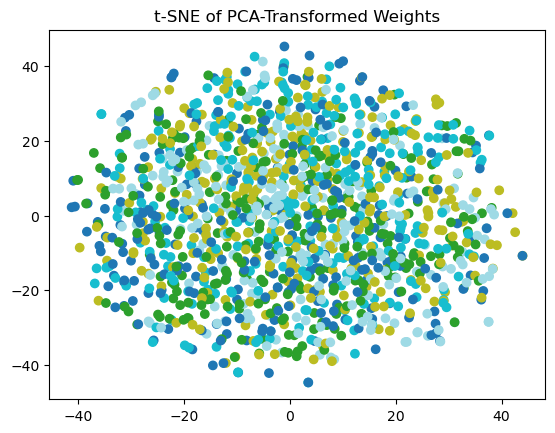

---------------- B1 --------------
                   Multivariate linear model
                                                               
---------------------------------------------------------------
      group_effect      Value   Num DF   Den DF  F Value Pr > F
---------------------------------------------------------------
          Wilks' lambda 0.9115 32.0000 5035.4665  4.0040 0.0000
         Pillai's trace 0.0904 32.0000 5472.0000  3.9527 0.0000
 Hotelling-Lawley trace 0.0950 32.0000 3559.3279  4.0508 0.0000
    Roy's greatest root 0.0674  8.0000 1368.0000 11.5207 0.0000



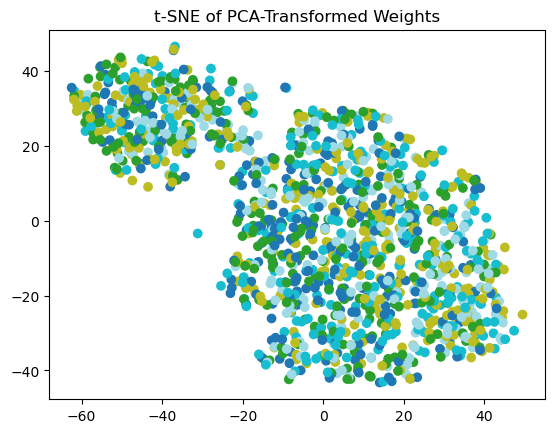

---------------- B2 --------------
                   Multivariate linear model
                                                               
---------------------------------------------------------------
      group_effect      Value   Num DF   Den DF  F Value Pr > F
---------------------------------------------------------------
          Wilks' lambda 0.6541 32.0000 5035.4665 19.1965 0.0000
         Pillai's trace 0.3795 32.0000 5472.0000 17.9228 0.0000
 Hotelling-Lawley trace 0.4788 32.0000 3559.3279 20.4035 0.0000
    Roy's greatest root 0.3494  8.0000 1368.0000 59.7424 0.0000



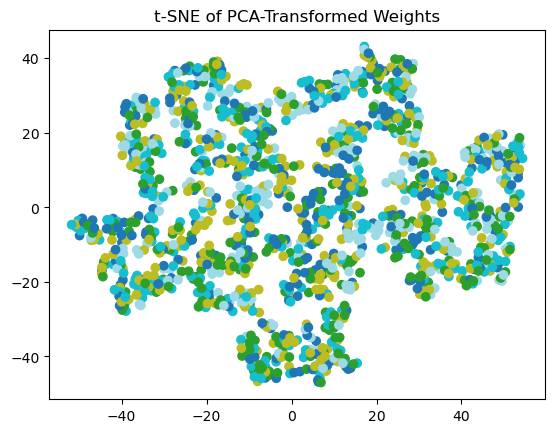

In [ ]:
print("---------------- W2 --------------")
manova_model = MANOVA(pca_w2, design_matrix)
# Test the hypothesis: "Do groups affect the PCA-transformed weights?"
hypothesis_matrix = np.eye(design_matrix.shape[1])[1:]  # Test all group coefficients (ignore intercept)
result = manova_model.mv_test(hypotheses=[('group_effect', hypothesis_matrix)])
# Print results
print(result.summary())
w2_tsne = TSNE(n_components=2,max_iter=3000).fit_transform(StandardScaler().fit_transform(pca_w2))
# Plot with group colors
plt.scatter(w2_tsne[:, 0], w2_tsne[:, 1], c=group_labels, cmap='tab20')
plt.title("t-SNE of PCA-Transformed Weights")
plt.show()
print("---------------- B1 --------------")
manova_model = MANOVA(pca_b1, design_matrix)
# Test the hypothesis: "Do groups affect the PCA-transformed weights?"
hypothesis_matrix = np.eye(design_matrix.shape[1])[1:]  # Test all group coefficients (ignore intercept)
result = manova_model.mv_test(hypotheses=[('group_effect', hypothesis_matrix)])
# Print results
print(result.summary())
b1_tsne = TSNE(n_components=2,max_iter=3000).fit_transform(StandardScaler().fit_transform(pca_b1))
# Plot with group colors
plt.scatter(b1_tsne[:, 0], b1_tsne[:, 1], c=group_labels, cmap='tab20')
plt.title("t-SNE of PCA-Transformed Weights")
plt.show()
print("---------------- B2 --------------")
manova_model = MANOVA(pca_b2, design_matrix)
# Test the hypothesis: "Do groups affect the PCA-transformed weights?"
hypothesis_matrix = np.eye(design_matrix.shape[1])[1:]  # Test all group coefficients (ignore intercept)
result = manova_model.mv_test(hypotheses=[('group_effect', hypothesis_matrix)])
# Print results
print(result.summary())
b2_tsne = TSNE(n_components=2,max_iter=3000).fit_transform(StandardScaler().fit_transform(pca_b2))
# Plot with group colors
plt.scatter(b2_tsne[:, 0], b2_tsne[:, 1], c=group_labels, cmap='tab20')
plt.title("t-SNE of PCA-Transformed Weights")
plt.show()

In [33]:
silhouette_score = sklearn.metrics.silhouette_score(pca_w1, labels)
print(f"Silhouette score (W1): {silhouette_score}")
silhouette_score = sklearn.metrics.silhouette_score(pca_w2, labels)
print(f"Silhouette score (W2): {silhouette_score}")
silhouette_score = sklearn.metrics.silhouette_score(pca_b1, labels)
print(f"Silhouette score (b1): {silhouette_score}")
silhouette_score = sklearn.metrics.silhouette_score(pca_b2, labels)
print(f"Silhouette score (b2): {silhouette_score}")

Silhouette score (W1): -0.028595568612217903
Silhouette score (W2): -0.023630686104297638
Silhouette score (b1): -0.028561268001794815
Silhouette score (b2): -0.03185204043984413


In [36]:
calinski_harabasz_w1 = sklearn.metrics.calinski_harabasz_score(pca_w1, labels)
print(f"Calinsk-Harabasz score (W1): ", calinski_harabasz_w1)
calinski_harabasz_w2 = sklearn.metrics.calinski_harabasz_score(pca_w2, labels)
print(f"Calinsk-Harabasz score (W2): ", calinski_harabasz_w2)
calinski_harabasz_b1 = sklearn.metrics.calinski_harabasz_score(pca_b1, labels)
print(f"Calinsk-Harabasz score (b1): ", calinski_harabasz_b1)
calinski_harabasz_b2 = sklearn.metrics.calinski_harabasz_score(pca_b2, labels)
print(f"Calinsk-Harabasz score (b2): ", calinski_harabasz_b2)

Calinsk-Harabasz score (W1):  3.350630505402728
Calinsk-Harabasz score (W2):  8.166715722682094
Calinsk-Harabasz score (b1):  3.261496191305781
Calinsk-Harabasz score (b2):  6.855194590580305


In [41]:
from skbio.stats.distance import permanova, DistanceMatrix
from scipy.spatial.distance import pdist, squareform

In [44]:
print("============= PERMANOVA W1 =============")
distance_matrix = squareform(pdist(pca_w1, 'cosine'))
permanova_result = permanova(DistanceMatrix(distance_matrix), labels, permutations=999)
print(permanova_result)

print("============= PERMANOVA W2 =============")
distance_matrix = squareform(pdist(pca_w2, 'cosine'))
permanova_result = permanova(DistanceMatrix(distance_matrix), labels, permutations=999)
print(permanova_result)

print("============= PERMANOVA b1 =============")
distance_matrix = squareform(pdist(pca_b1, 'cosine'))
permanova_result = permanova(DistanceMatrix(distance_matrix), labels, permutations=999)
print(permanova_result)

print("============= PERMANOVA b2 =============")
distance_matrix = squareform(pdist(pca_b2, 'cosine'))
permanova_result = permanova(DistanceMatrix(distance_matrix), labels, permutations=999)
print(permanova_result)

print("============= PERMANOVA act1 =============")
distance_matrix = squareform(pdist(act1, 'euclidean'))
permanova_result = permanova(DistanceMatrix(distance_matrix), labels, permutations=999)
print(permanova_result)

print("============= PERMANOVA act2 =============")
distance_matrix = squareform(pdist(act2, 'euclidean'))
print(distance_matrix.shape)
permanova_result = permanova(DistanceMatrix(distance_matrix), labels, permutations=999)
print(permanova_result)

============= PERMANOVA W1 =============
method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1377
number of groups                  5
test statistic             1.073465
p-value                       0.362
number of permutations          999
Name: PERMANOVA results, dtype: object
============= PERMANOVA W2 =============
method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1377
number of groups                  5
test statistic             0.824752
p-value                       0.582
number of permutations          999
Name: PERMANOVA results, dtype: object
============= PERMANOVA b1 =============
method name               PERMANOVA
test statistic name        pseudo-F
sample size                    1377
number of groups                  5
test statistic              0.80938
p-value                       0.602
number of permutations          999
Name: PERMANOVA results, dtype: object
====